In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully")

Libraries loaded successfully


In [9]:
import os
os.listdir("../data")

['movie-recommendation-hackathon-2026']

In [10]:
os.listdir("../data/movie-recommendation-hackathon-2026")

['genome_scores.csv',
 'genome_tags.csv',
 'imdb_data.csv',
 'links.csv',
 'movies.csv',
 'sample_submission.csv',
 'tags.csv',
 'test.csv',
 'train.csv']

In [12]:
train = pd.read_csv("../data/movie-recommendation-hackathon-2026/train.csv")
test = pd.read_csv("../data/movie-recommendation-hackathon-2026/test.csv")
movies = pd.read_csv("../data/movie-recommendation-hackathon-2026/movies.csv")
imdb = pd.read_csv("../data/movie-recommendation-hackathon-2026/imdb_data.csv")
links = pd.read_csv("../data/movie-recommendation-hackathon-2026/links.csv")
tags = pd.read_csv("../data/movie-recommendation-hackathon-2026/tags.csv")

In [14]:
print("Dataset Shapes")
print("-" * 40)

print(f"Train dataset : {train.shape}")
print(f"Test dataset  : {test.shape}")
print(f"Movies dataset: {movies.shape}")
print(f"IMDb dataset  : {imdb.shape}")
print(f"Links dataset : {links.shape}")
print(f"Tags dataset  : {tags.shape}")

Dataset Shapes
----------------------------------------
Train dataset : (10000038, 4)
Test dataset  : (5000019, 2)
Movies dataset: (62423, 3)
IMDb dataset  : (27278, 6)
Links dataset : (62423, 3)
Tags dataset  : (1093360, 4)


In [16]:
for name, df in [
    ("Train", train),
    ("Test", test),
    ("Movies", movies),
    ("IMDb", imdb),
    ("Links", links),
    ("Tags", tags)
]:
    print(f"\n{name} Dataset")
    print("-" * 30)
    print(df.columns.tolist())


Train Dataset
------------------------------
['userId', 'movieId', 'rating', 'timestamp']

Test Dataset
------------------------------
['userId', 'movieId']

Movies Dataset
------------------------------
['movieId', 'title', 'genres']

IMDb Dataset
------------------------------
['movieId', 'title_cast', 'director', 'runtime', 'budget', 'plot_keywords']

Links Dataset
------------------------------
['movieId', 'imdbId', 'tmdbId']

Tags Dataset
------------------------------
['userId', 'movieId', 'tag', 'timestamp']


In [17]:
train.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [18]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [19]:
imdb.head()

,movieId,title_cast,director,runtime,budget,plot_keywords
0,1,Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wal...,John Lasseter,81.0,"$30,000,000",toy|rivalry|cowboy|cgi animation
1,2,Robin Williams|Jonathan Hyde|Kirsten Dunst|Bra...,Jonathan Hensleigh,104.0,"$65,000,000",board game|adventurer|fight|game
2,3,Walter Matthau|Jack Lemmon|Sophia Loren|Ann-Ma...,Mark Steven Johnson,101.0,"$25,000,000",boat|lake|neighbor|rivalry
3,4,Whitney Houston|Angela Bassett|Loretta Devine|...,Terry McMillan,124.0,"$16,000,000",black american|husband wife relationship|betra...
4,5,Steve Martin|Diane Keaton|Martin Short|Kimberl...,Albert Hackett,106.0,"$30,000,000",fatherhood|doberman|dog|mansion


# Each row  will look like this:
# (userId, movieId) -> rating

In [16]:
# Create a clean trainning view
train_data = train.copy()

train_data.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [17]:
#connects IDs to real movie names
df = train_data.merge(movies, on="movieId", how="left")
df.head()

,userId,movieId,rating,timestamp,title,genres
0,5163,57669,4.0,1518349992,In Bruges (2008),Comedy|Crime|Drama|Thriller
1,106343,5,4.5,1206238739,Father of the Bride Part II (1995),Comedy
2,146790,5459,5.0,1076215539,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,Action|Comedy|Sci-Fi
3,106362,32296,2.0,1423042565,Miss Congeniality 2: Armed and Fabulous (2005),Adventure|Comedy|Crime
4,9041,366,3.0,833375837,Wes Craven's New Nightmare (Nightmare on Elm S...,Drama|Horror|Mystery|Thriller


In [19]:
#Check what the model will learn
print("Input features:")
print(df[["userId", "movieId"]].head())

print("\nTarget variable (what we predict):")
print(df["rating"].head())

Input features:
   userId  movieId
0    5163    57669
1  106343        5
2  146790     5459
3  106362    32296
4    9041      366

Target variable (what we predict):
0    4.0
1    4.5
2    5.0
3    2.0
4    3.0
Name: rating, dtype: float64


In [21]:
#Understand rating distribution
df["rating"].describe()

count    1.000004e+07
mean     3.533395e+00
std      1.061124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

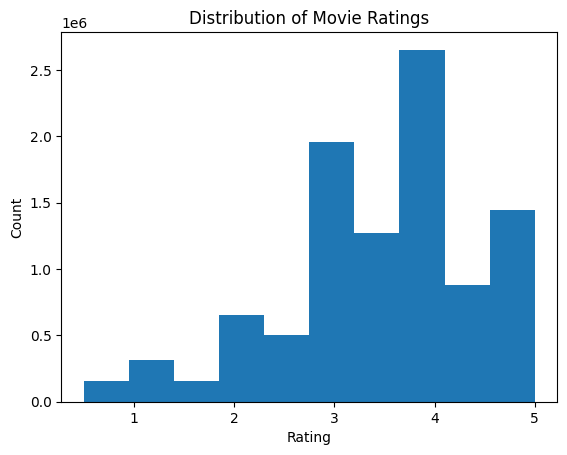

In [22]:
#Visualizing the problem
import matplotlib.pyplot as plt

plt.hist(df["rating"], bins=10)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [24]:
#ML problem clearly confirming
print("We are solving:")
print("INPUT: userId + movieId")
print("OUTPUT: rating prediction")

We are solving:
INPUT: userId + movieId
OUTPUT: rating prediction


## Next Session

- Continue recommendation model development.
- Test recommendation outputs.
- Save model artifacts.
- Prepare final report.

In [1]:
print("Datasets Available")
print("-" * 40)

print("1. train_df")
print("2. movies_df")
print("3. imdb_df")

Datasets Available
----------------------------------------
1. train_df
2. movies_df
3. imdb_df


In [5]:
print("Dataset Shapes")
print("-" * 40)

print(f"Train dataset : {train_data.shape}")
print(f"Movies dataset: {movies.shape}")
print(f"IMDB dataset  : {imdb.shape}")

Dataset Shapes
----------------------------------------


NameError: name 'train_data' is not defined